In [1]:
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
import pandas as pd
import json
import numpy as np
from collections import Counter
import ast

In [2]:
def similar1(curve1,curve2):
    if (max(curve1)-min(curve1))>0:
        curve1 = [(i-min(curve1))/(max(curve1)-min(curve1)) for i in curve1]
    if (max(curve2)-min(curve2))>0:
        curve2 = [(i-min(curve2))/(max(curve2)-min(curve2)) for i in curve2]

    # 定义距离函数，这里使用欧氏距离
    distance = lambda x, y: euclidean(x, y)

    # 使用fastdtw计算DTW距离
    distance, path = fastdtw(curve1, curve2, dist=distance)

    # 输出DTW距离和对齐路径
#     print("DTW Distance:", distance)
    return distance

In [3]:
df = pd.read_excel("Data of collaboration trajectories.xlsx")
df.head()

,机构,姓名,年份,年龄,广度,标准化广度,深度,标准化深度,C指数,标准化C指数,研究领域,学科
0,北京邮电大学,杨义先,1994,4,1,0.000000,1,0.0,1,0.0,信号与信息处理,工程
1,北京邮电大学,杨义先,1995,5,1,0.000000,1,0.0,1,0.0,信号与信息处理,工程
2,北京邮电大学,杨义先,1996,6,1,0.000000,1,0.0,1,0.0,信号与信息处理,工程
3,北京邮电大学,杨义先,1997,7,1,0.000000,1,0.0,1,0.0,信号与信息处理,工程
4,北京邮电大学,杨义先,1998,8,3,0.005222,1,0.0,1,0.0,信号与信息处理,工程


In [4]:
df['机构__姓名'] = [f"{df.iloc[i,0]}__{df.iloc[i,1]}" for i in range(df.shape[0])]
list3 = list(set(df['机构__姓名'].tolist()))
list4 = []
# 创建相似性矩阵
similarity_matrix = np.zeros((len(list3), len(list3)))
for i in range(len(list3)):
    for j in range(i+1,len(list3)):
        curve1 = df[df['机构__姓名']==list3[i]]['广度'].tolist()
        curve2 = df[df['机构__姓名']==list3[j]]['广度'].tolist()
        similar = similar1(curve1,curve2)
        list4.append([list3[i],list3[j],similar])
        similarity_matrix[i][j] = similar
        similarity_matrix[j][i] = similar  # 如果相似性是对称的，同时填充对角线上的值

In [5]:
df11 = pd.DataFrame(similarity_matrix,columns=[item for item in list3])
df11.to_excel(f'职业年龄大于等于20岁的{len(list3)}个学者合作广度距离矩阵.xlsx', index=False)

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

distance_matrix = similarity_matrix
new_matrix = distance_matrix
# 初始化聚类个数的范围
min_k = 2
max_k = 50
k_values = range(min_k, max_k+1)

# 存储每个聚类个数对应的评估指标值
inertia_values = []
silhouette_scores = []

# 遍历不同的聚类个数
for k in k_values:
    # 使用K-means聚类
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(new_matrix)
    
    # 计算簇内平方和（inertia）
    inertia_values.append(kmeans.inertia_)
    
    # 计算轮廓系数
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(new_matrix, labels, metric='euclidean'))

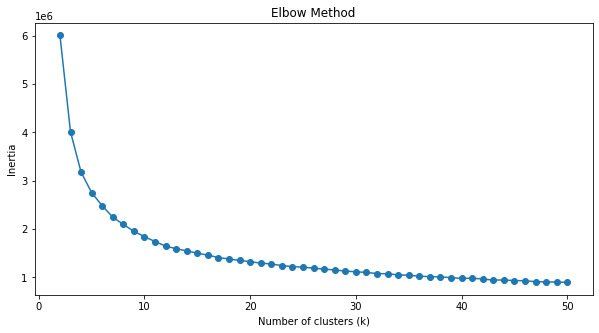

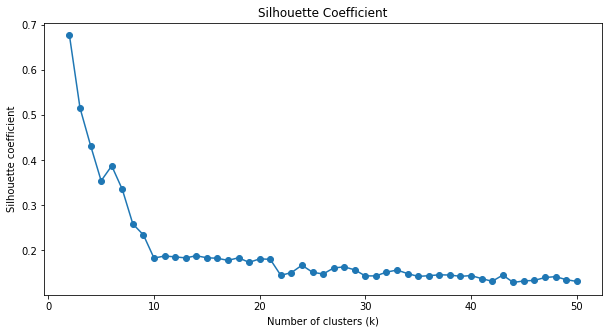

In [7]:
# 绘制肘部法则曲线
plt.figure(figsize=(10, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# 绘制轮廓系数曲线
plt.figure(figsize=(10, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette coefficient')
plt.title('Silhouette Coefficient')
plt.show()

In [8]:
# 构建DataFrame
data = {'聚类个数': [i for i in k_values], '簇内平方和': inertia_values, '轮廓系数': silhouette_scores}
df = pd.DataFrame(data)
df.to_excel('合作广度成长轨迹聚类个数判断数据.xlsx',index=False)

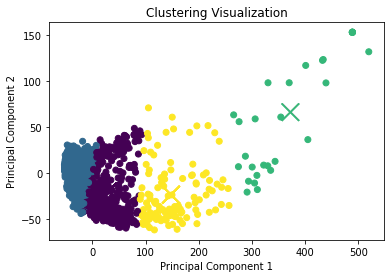

In [9]:
from sklearn.decomposition import PCA
kmeans = KMeans(n_clusters=4)
kmeans.fit(new_matrix)
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(new_matrix)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=kmeans.labels_)
xlist,ylist = [],[]
for i in kmeans.labels_:
    x1 = reduced_data[[j for j, item in enumerate(kmeans.labels_) if item == i],0]
    y1 = reduced_data[[j for j, item in enumerate(kmeans.labels_) if item == i],1]
    xlist.append(sum(x1)/len(x1))
    ylist.append(sum(y1)/len(y1))
    
plt.scatter(xlist, ylist, c=kmeans.labels_, marker='x', label='Cluster Centers',s=300,alpha=0.1)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clustering Visualization')
plt.show()

In [10]:
list1 = []
for i in set(kmeans.labels_):
    x1 = reduced_data[[j for j, item in enumerate(kmeans.labels_) if item == i],0]
    y1 = reduced_data[[j for j, item in enumerate(kmeans.labels_) if item == i],1]
    for i1 in range(len(x1)):
        list1.append([x1[i1],y1[i1],i,'normal'])
    list1.append([sum(x1)/len(x1),sum(y1)/len(y1),i,'mean'])
df = pd.DataFrame(list1,columns=['x','y','聚类类别','类型'])
df.to_excel('合作广度主成分分析聚类结果.xlsx',index=False)